Step1: Import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn 

In [2]:
from keras.datasets import cifar10
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

In [3]:
X_train.shape #3 is the channels red,green,blue

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_test.shape

(10000, 1)

Step2 : Visualize data

[0]


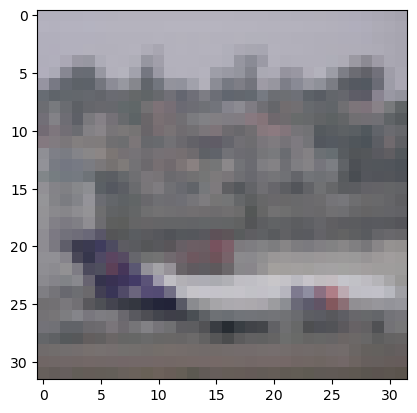

In [8]:
i = 30000
plt.imshow(X_train[i])
print(y_train[i])

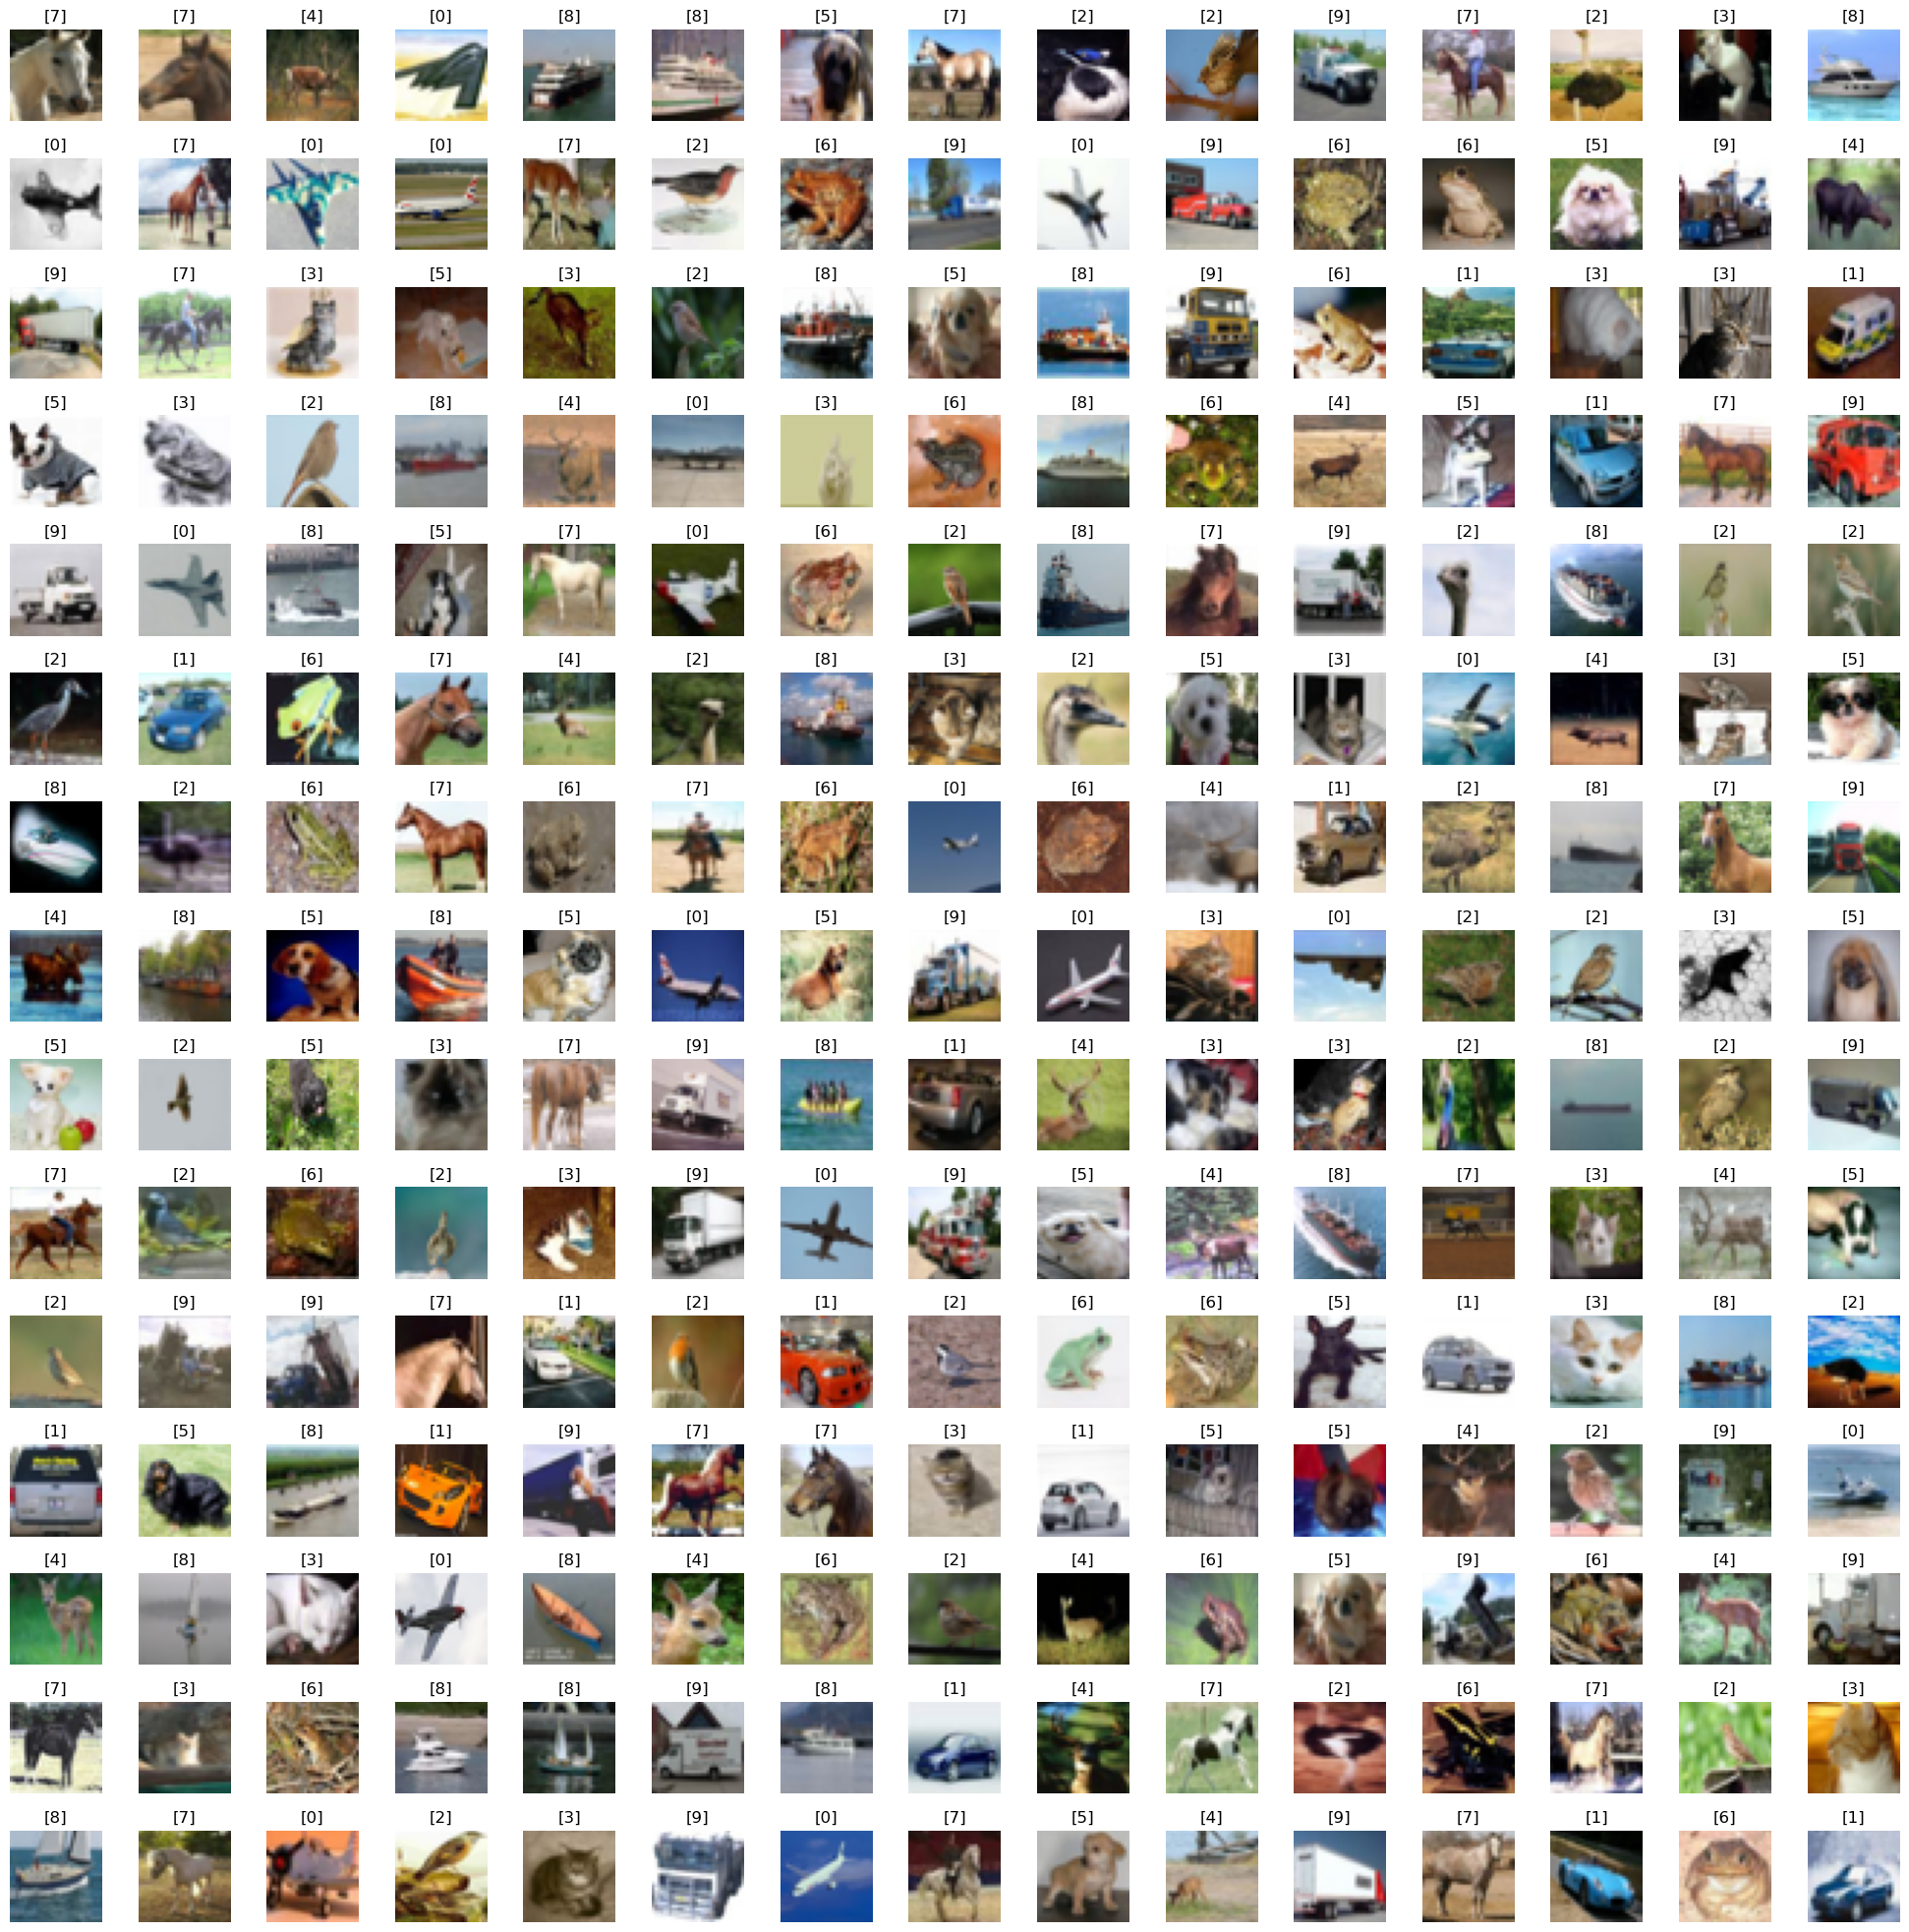

In [9]:
W_grid = 15
L_grid = 15

fig,axes = plt.subplots(L_grid,W_grid,figsize = (25,25))
axes = axes.ravel()

n_training = len(X_train)

for i in np.arange(0,L_grid*W_grid):
    index=np.random.randint(0,n_training)#pick random number
    axes[i].imshow(X_train[index])
    axes[i].set_title(y_train[index])
    axes[i].axis('off')
plt.subplots_adjust(hspace = 0.4)

In [10]:
n_training

50000

Step3: Data preparation

In [12]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [13]:
number_cat = 10

In [14]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [15]:
import keras
y_train = keras.utils.to_categorical(y_train, number_cat)

In [16]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [17]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [18]:
import keras
y_test = keras.utils.to_categorical(y_test, number_cat)

In [19]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [20]:
X_train = X_train/255
X_test = X_test/255

In [21]:
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [22]:
X_train.shape

(50000, 32, 32, 3)

In [23]:
Input_shape = X_train.shape[1:]

In [24]:
Input_shape

(32, 32, 3)

Step4: Train the model

In [26]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Dense, Flatten , Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

In [27]:
cnn_model = Sequential()
cnn_model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', input_shape = Input_shape))
cnn_model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Dropout(0.4))

cnn_model.add(Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu'))
cnn_model.add(Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Dropout(0.4))

cnn_model.add(Flatten())

cnn_model.add(Dense(units = 1024, activation='relu'))
cnn_model.add(Dense(units = 1024, activation='relu'))

cnn_model.add(Dense(units= 10, activation='softmax')) #0or1 output so softmax

D:\User\a\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
y_train.shape

(50000, 10)

In [29]:
cnn_model.compile(loss = 'categorical_crossentropy', optimizer = keras.optimizers.RMSprop(learning_rate = 0.001), metrics =['accuracy'])

In [30]:
history = cnn_model.fit(X_train, y_train, batch_size=32, epochs=2, shuffle=True)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 263s 164ms/step - accuracy: 0.3010 - loss: 1.9004
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 258s 165ms/step - accuracy: 0.5682 - loss: 1.2277


Step5: Evaluate the model

In [32]:
evaluation = cnn_model.evaluate(X_test,y_test)
print('Test Accuracy: {}'.format(evaluation[1]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.6153 - loss: 1.1146
Test Accuracy: 0.6097000241279602


In [54]:
predicted_classes = cnn_model.predict(X_test)
predicted_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step


array([[1.9802991e-02, 2.6232349e-03, 4.0052203e-03, ..., 1.3026620e-03,
        7.9415709e-01, 1.7176495e-03],
       [1.8687759e-02, 1.7691463e-02, 9.8673063e-06, ..., 3.1049531e-08,
        9.6289784e-01, 7.0944469e-04],
       [1.4179094e-01, 1.8137621e-02, 1.4325127e-03, ..., 8.0747035e-05,
        8.2333046e-01, 1.4266285e-02],
       ...,
       [6.4621225e-04, 8.1737860e-05, 7.0025884e-02, ..., 3.4260310e-02,
        3.4205054e-04, 5.7343085e-04],
       [4.9084696e-01, 5.1878363e-02, 1.5142061e-01, ..., 2.2176148e-03,
        8.8024689e-03, 2.6613791e-03],
       [1.3519214e-07, 1.1958762e-10, 4.5316734e-05, ..., 9.8365515e-01,
        7.7160042e-11, 2.5631850e-09]], dtype=float32)

In [36]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [46]:
y_test = y_test.argmax(1)

AxisError: axis 1 is out of bounds for array of dimension 1

In [48]:
y_test

array([3, 8, 8, ..., 5, 1, 7], dtype=int64)

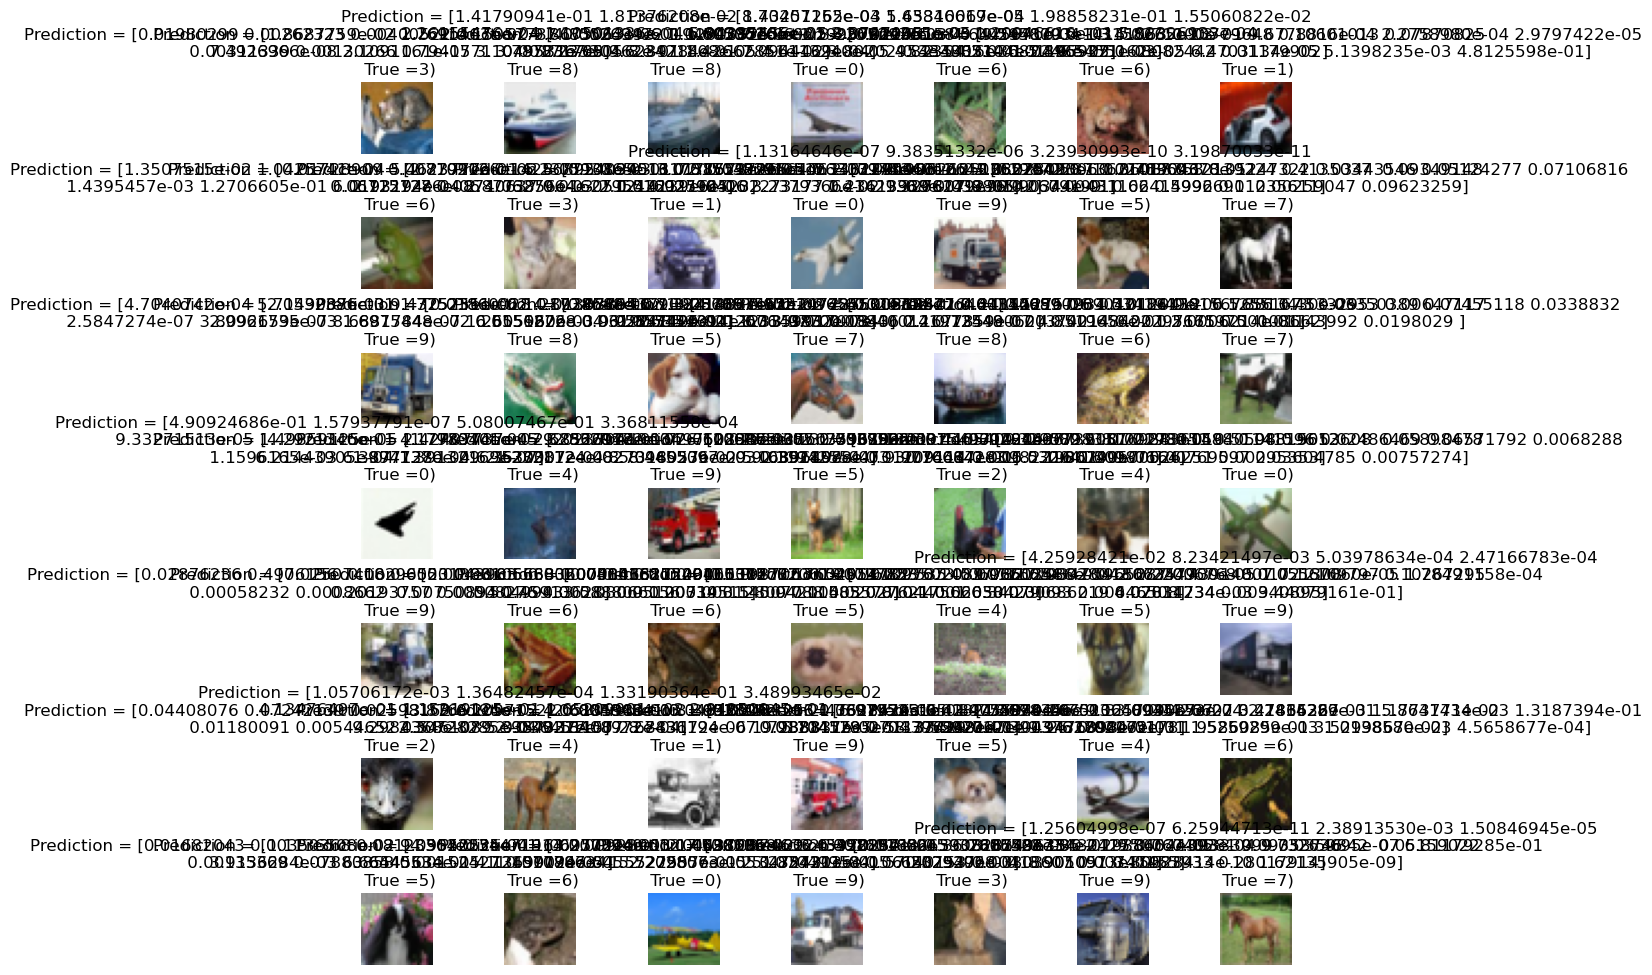

In [52]:
L =7
W=7
fig,axes = plt.subplots(L,W,figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0,L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('Prediction = {}\n True ={})'.format(predicted_classes[i],y_test[i]))
    axes[i].axis('off')
plt.subplots_adjust(wspace = 1)
    

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)
cm
plt.figure(figsize = (10, 10))
sns.heatmap(cm, annot = True)

ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets